## Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
from matplotlib import pyplot as plt

## The Data

In [18]:
#read the dataset
df = pd.read_csv("input/Stack_4.csv")
#df = pd.read_csv("Standardized_Data.csv")
df.head()

,light,Shadow_Sha,GPS,VGA_connec,Newid
0,-0.676648,-0.794581,-0.843857,-1.000000,1
1,-0.676648,-0.219912,-0.968782,0.838172,2
2,-0.676648,-0.521109,-1.000000,0.838172,3
3,-0.676648,-0.411468,-1.000000,0.838172,4
4,-0.676648,-0.465658,-1.000000,0.691458,5


In [19]:
df.shape

(176256, 5)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176256 entries, 0 to 176255
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   light       176256 non-null  float64
 1   Shadow_Sha  176256 non-null  float64
 2   GPS         176256 non-null  float64
 3   VGA_connec  176256 non-null  float64
 4   Newid       176256 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 6.7 MB


In [21]:
df.columns

Index(['light', 'Shadow_Sha', 'GPS', 'VGA_connec', 'Newid'], dtype='object')

## Clean DATA

In [22]:
data=df[[ 'light', 'Shadow_Sha', 'GPS', 'VGA_connec']]


In [23]:
data.shape

(176256, 4)

In [24]:
data.head()

,light,Shadow_Sha,GPS,VGA_connec
0,-0.676648,-0.794581,-0.843857,-1.000000
1,-0.676648,-0.219912,-0.968782,0.838172
2,-0.676648,-0.521109,-1.000000,0.838172
3,-0.676648,-0.411468,-1.000000,0.838172
4,-0.676648,-0.465658,-1.000000,0.691458


In [25]:
data.isnull().values.any()

np.False_

In [26]:
datalocation=df[['Newid']]

In [27]:
datalocation.head()

,Newid
0,1
1,2
2,3
3,4
4,5


## Visualisation

In [28]:
data.corr()

,light,Shadow_Sha,GPS,VGA_connec
light,1.000000,-0.040028,0.158100,-0.304147
Shadow_Sha,-0.040028,1.000000,-0.124149,-0.209778
GPS,0.158100,-0.124149,1.000000,-0.215042
VGA_connec,-0.304147,-0.209778,-0.215042,1.000000


## DIVIDE DATA FOR ANALYSIS

In [29]:
#the data should be doublicated in order to run the analysis independantly
data1=data.copy()
data2=data.copy()

# Alternative you can divide the code into 2 files. DO NOT USE PCA data in KMEANS or the opposite

## K-Means Clustering

### A. Define the number of clusters (Elbow method)

In [30]:
#Fit data and calculate sum of squares(wss)
wss=[]
from sklearn.cluster import KMeans

for i in range (1,21):    
    kmeans=KMeans(n_clusters=i,init="k-means++")
    kmeans.fit(data1)
    wss.append(kmeans.inertia_)

C:\Users\32003\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\32003\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\32003\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\32003\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
      

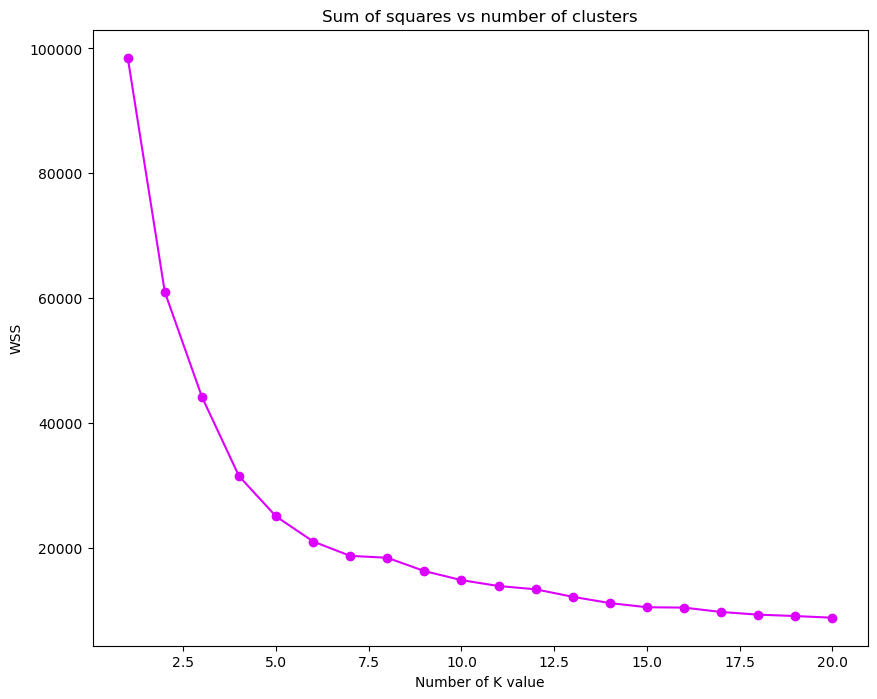

In [31]:
#Visualisation of the k values in order to define the fittest
plt.figure(figsize=(10,8))
plt.plot(range(1,21),wss,marker="o", color="#dc00ff")
plt.xlabel("Number of K value")
plt.ylabel("WSS")
plt.title("Sum of squares vs number of clusters")
#plt.savefig("Elbow.png", dpi=300,transparent=True)
plt.show()

### B.Clustering the data

In [32]:
#import library
from sklearn.cluster import KMeans

In [33]:
#pick number of clusters
kmeans = KMeans(n_clusters=4)

In [34]:
#fit the data
kmeans.fit(data1)

KMeans(n_clusters=4)

In [35]:
#find the cluster centers
kmeans.cluster_centers_

array([[-0.72348587, -0.5921919 , -0.97731006,  0.10396742],
       [-0.53303218,  0.13105597, -0.97528801, -0.87397928],
       [-0.58384805, -0.65814423, -0.92931684, -0.79998223],
       [ 0.39995946, -0.66678488, -0.90236475, -0.69367424]])

In [36]:
#identify cluster labels
kmeans.labels_

array([2, 0, 0, ..., 2, 2, 2], dtype=int32)

In [37]:
#identify length of cluster labels
len(kmeans.labels_)

176256

In [38]:
#Add cluster column in dataset
data1['CLUSTERS'] = kmeans.fit_predict(data1)

In [39]:
data1.head()

,light,Shadow_Sha,GPS,VGA_connec,CLUSTERS
0,-0.676648,-0.794581,-0.843857,-1.000000,3
1,-0.676648,-0.219912,-0.968782,0.838172,1
2,-0.676648,-0.521109,-1.000000,0.838172,1
3,-0.676648,-0.411468,-1.000000,0.838172,1
4,-0.676648,-0.465658,-1.000000,0.691458,1


In [40]:
#Count how many belong to each cluster
data1['CLUSTERS'].value_counts()

CLUSTERS
3    64708
1    55100
0    39410
2    17038
Name: count, dtype: int64

### C.Visualise your Kmeans result

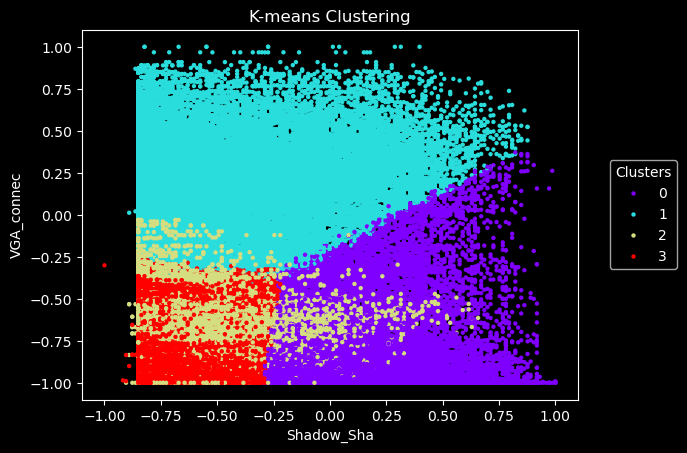

In [49]:
'''
#Scatterplot of clustered data
sns.scatterplot(x=data1['vnl_NightLightmean'], y=data1['BAME%_re'], hue= kmeans.labels_, palette='rainbow')
plt.title('K-means Clustering')
plt.legend(loc=0,bbox_to_anchor=(1.2,0.5),title="Clusters")
plt.show()
'''

# Set the overall chart background to black (the font and axes will automatically turn white to match).
plt.style.use('dark_background')

# To draw a scatter plot, add `edgecolor='none'` to remove the white borders around the points.
sns.scatterplot(
    x=data1['Shadow_Sha'], 
    y=data1['VGA_connec'], 
    hue=kmeans.labels_, 
    palette='rainbow',
    edgecolor='none' ,
    s=10
)

plt.title('K-means Clustering')
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), title="Clusters")
plt.show()

#### Bring back data location to map in QGIS

In [42]:
final_df = pd.concat([datalocation, data1], axis=1)
final_df.head()

,Newid,light,Shadow_Sha,GPS,VGA_connec,CLUSTERS
0,1,-0.676648,-0.794581,-0.843857,-1.000000,3
1,2,-0.676648,-0.219912,-0.968782,0.838172,1
2,3,-0.676648,-0.521109,-1.000000,0.838172,1
3,4,-0.676648,-0.411468,-1.000000,0.838172,1
4,5,-0.676648,-0.465658,-1.000000,0.691458,1


In [43]:
final_df[final_df['CLUSTERS'] == 0]

,Newid,light,Shadow_Sha,GPS,VGA_connec,CLUSTERS
145,146,-0.830427,-0.260239,-1.000000,-1.000000,0
148,149,-0.830427,-0.096408,-0.990865,-1.000000,0
167,168,-0.704474,-0.068683,-1.000000,-0.387043,0
168,169,-0.704474,-0.027095,-1.000000,-0.387043,0
173,174,-0.704474,-0.246377,-0.981308,-1.000000,0
...,...,...,...,...,...,...
176237,176238,-0.240905,0.122873,-1.000000,-0.859214,0
176238,176239,-0.240905,-0.206049,-1.000000,-0.859214,0
176239,176240,-0.240905,-0.136736,-1.000000,-0.859214,0
176240,176241,-0.240905,0.040958,-1.000000,-0.859214,0


In [45]:
final_df.to_csv('Stack Kmeans.csv', encoding='utf-8', index=False)

## Principal Component Analysis

### A. Preprocessing

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
scaler.fit(data2)

In [ ]:
scaled_data = scaler.transform(data2)

### B. Running PCA

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components=4)

In [ ]:
pca.fit(scaled_data)

In [ ]:
x_pca = pca.transform(scaled_data)

In [ ]:
scaled_data.shape #14 dimensions

In [ ]:
x_pca.shape #3 dimensions (to interpret it as a 3D; PC1, PC2, PC3)

### C.Interpretation of results

In [ ]:
pca.components_

In [ ]:
df_comp = pd.DataFrame(pca.components_,columns=data2.columns)

In [ ]:
cmap = sns.diverging_palette(180, 295, s=100, l=50,
                                  n=10, center= "dark", as_cmap = True)

#Documentation: https://seaborn.pydata.org/generated/seaborn.diverging_palette.html

In [ ]:
plt.figure(figsize=(40,12))
sns.heatmap(df_comp,cmap= cmap, annot=True,fmt = ".1f")

In [ ]:
df_comp.head()

In [ ]:
df=pd.DataFrame(x_pca, columns = ['0','1','2',"3"])

In [ ]:
df.head()

In [ ]:

datalocation.head()

In [ ]:
plt.figure(figsize=(16,12))

# Set figure background to black
fig = plt.gcf()
fig.patch.set_facecolor('black')

# Get current axes and set its background to black
ax = plt.gca()
ax.set_facecolor('black')

# Set tick parameters color to white
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

# 1. Find the maximum boundary of absolute values
limit = np.max(np.abs(corr.values))

# Define custom colormap with specified colors and black at center
custom_colors = ['#1900d2', '#00f1ff', 'black', '#de00ff', '#7e21ff']
cmap = LinearSegmentedColormap.from_list("my_custom_cmap", custom_colors)

# 2. Plotting
sns.heatmap(df_comp,
            cmap= cmap,
            annot=True,
            fmt = ".1f",
            vmin=-limit,
            vmax=limit,
            center=0,
            annot_kws={"color": "white"}) # Set annotation text color to white

# Set title and axis labels color to white
plt.title('Heatmap of PCA Components', color='white')
plt.xlabel('Features', color='white')
plt.ylabel('Principal Components', color='white')

# Adjust colorbar label and tick label color
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color='white')
cbar.ax.yaxis.label.set_color('white') # Set colorbar label color
plt.setp(cbar.ax.get_yticklabels(), color='white') # Set colorbar tick labels color to white

plt.show()

In [ ]:
df_prefinal=pd.concat([df,datalocation],axis=1)

In [ ]:
df_prefinal.head()

In [ ]:
df_final=pd.concat([df_prefinal, data1],axis=1)

In [ ]:
df_final.head()

In [44]:
df_final.to_csv('Stack Kmeans.csv', encoding='utf-8', index=False)
#df_final.to_csv('Phy Result 4PC 6Cl.csv', encoding='utf-8', index=False)

NameError: name 'df_final' is not defined